In [1]:
rm(list = ls())

In [2]:
.libPaths(c("~/R/library", .libPaths()))

library(labeling)
library(reshape2)
library(ggplot2)
library(RColorBrewer)
library(dplyr)
library(proxy)
library(IRdisplay)
#.libPaths("R/stringi")
library(stringi, lib.loc="~/R/library")
#library(stringi)  


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘proxy’


The following objects are masked from ‘package:stats’:

    as.dist, dist


The following object is masked from ‘package:base’:

    as.matrix




In [3]:
#--------------------- Usar assinaturas fixas caso o interesse -------------------------
#==========================================================================
# Exemplos de resultados que podem ser utilizados para fixar assinaturas
#==========================================================================

#source("Funcoes_analises_MEstudo.r") 


# Selecione rds aqui
#dados <- readRDS("Aq_rds/COAD_R5_MATH_SCORE_S_Rcpp.rds")
#dados <- readRDS("Aq_rds/COAD_R14_MATH_SCORE_S_Rcpp.rds")
#COAD_R14_MATH_SCORE_S_Rcpp.rds
#----------------------> Como acessar cada objeto <------------------------
# É preciso desabilitar P, E ou A que seja de interesse em fixar -------------


#dados$P_medio                   
#dados$E_list_medio 
#dados$A_list
#dados$BIC 
#dados$Menor_Math_Score_BLCA_S
#dados$Maior_Math_Score_BLCA_S   
#dados$dados_survival
#dados$informacoes 
   
#------ vizualizar assinaturas para escolher quais utilzar -------------------------

#display_markdown("## Escolher assinaturas para fixar")

#C3 <- c(
#rep("#EB7E6E", 16),
#rep("#FFB838", 16),
#rep("#F2DC6F", 16),
#rep("#ABE0EF", 16),
#rep("#51A7C0", 16),
#rep("#2184A1", 16)
#)

#Assinaturas_Mutacionais(dados$P_medio, cores = C3)

In [4]:
#source("Funcoes_analises_MEstudo.r") 

#dt <- read.table("COSMIC_v3.1_SBS_GRCh37.signeR.txt", header=T)
#attach(dt)
## M1
#P_medio <- matrix(c(SBS40, SBS6, SBS21, SBS1, SBS39, SBS7a,
#                   SBS10b, SBS46), byrow=F, ncol=8)

#P_medio <- matrix(c(SBS39, SBS10a, SBS21, SBS6, SBS46, SBS30,
#                   SBS3, SBS40, SBS10b, SBS1), byrow=F, ncol=10)

#dados <- list()             # criar lista 'dados' se ainda não existir
#dados$P_medio <- list(P_medio)

#dados$P_medio <- P_medio

#C3 <- c(
#rep("#EB7E6E", 16),
#rep("#FFB838", 16),
#rep("#F2DC6F", 16),
#rep("#ABE0EF", 16),
#rep("#51A7C0", 16),
#rep("#2184A1", 16)
#)

#Assinaturas_Mutacionais(dados$P_medio, cores = C3)

In [5]:
#P_filtrado <- dados$P_medio[, -c(4)]
#dados$P_medio <- P_filtrado
#Assinaturas_Mutacionais(P_filtrado, cores = C3)

In [6]:
#P <- dados$P_medio #<-------puxando valor do rds se for o interesse

#Fixando Matriz A com diagonal inteira 1

n_assinaturas <- 8

# Criar matriz diagonal com 1
matrizA <- diag(1, nrow = n_assinaturas, ncol = n_assinaturas)

# Criar lista dentro da estrutura 'dados'
dados <- list()             # criar lista 'dados' se ainda não existir
dados$A_list <- list(matrizA, matrizA)   #<----- modificar aqui para ser uma ou duas
#dados$P <- P  #<-------puxando valor do rds se for o interesse
# Conferir
str(dados$A_list)

List of 2
 $ : num [1:8, 1:8] 1 0 0 0 0 0 0 0 0 1 ...
 $ : num [1:8, 1:8] 1 0 0 0 0 0 0 0 0 1 ...


In [45]:
# ---------------------------
# Parâmetros
# ---------------------------
i <- 96
n_signatures <- 8
S <- 1
num_iterations <- 13000

#--------------------
# Hiper Multi-Estudo
#--------------------
#ap = 5 
#bp = 0.05
#ae = 5
#be = 0.01 
#lp = 0.5
#le = 0.1  


#--------------------
# Hiper SigneR
#--------------------
ap <- 0.8005
bp <- 0.043
ae <- 2.0506
be <- 1.325
lp <- 5.3329
le <- 1.436

# Fix columns como vetores inteiros (vazios se não houver colunas fixas)
fix_colsP <- integer(0)   
#fix_colsA <- integer(0)    
fix_colsE <- integer(0)

#====================
# Se houver fixas
#===================

#fix_colsP <- c(1:8)
fix_colsA <- c(1:8)
#fix_colsE <- c(1, 2, 3, 4, 5, 6, 7, 8)

eps <- .Machine$double.xmin  

#df1 <- read.table("countsMATH_menos_expostos_COAD.txt", header = FALSE, sep = "\t")

#df2 <- read.table("countsMATH_mais_expostos_COAD.txt", header = FALSE, sep = "\t")

#data <- list(df1, df2)

df1 <- read.table("countsMATH_COAD.txt", header = FALSE, sep = "\t") 
#df1 <- read.table("countsMATH_mais_expostos_COAD.txt", header = FALSE, sep = "\t") 
data <- list(df1)

source("De_novo.R")  

#========================================================================================================
# Selecionar abaixo e desligar source("De_novo.R") quando houver a intenção de fixar assinaturas
# e descobrir novas

#source("Reajuste.R")

#========================================================================================================

# =======================================================
# Exemplo abaixo para quando houver mais de dois estudos
# =======================================================

# df1 <- read.table("SKCM_stageI_filtered_counts.txt", header = FALSE, sep = "\t") 

# df2 <- read.table("SKCM_stageII_filtered_counts.txt", header = FALSE, sep = "\t")

# df3 <- read.table("SKCM_stageIII_filtered_counts.txt", header = FALSE, sep = "\t")

# df4 <- read.table("SKCM_stageIV_filtered_counts.txt", header = FALSE, sep = "\t")

# data <- list(df1, df2, df3, df4)    #<---- df1, df2, df3 e etc
#-------------------------------------------------------------------------

#============================
# Acesso a resultados
# ===========================

#dados$P_medio     
#dados$E_list_medio                   
#dados$A_list       
#dados$BIC          
#dados$rank_choice  

Rank choices disponíveis: 1 
Melhor rank_choice: 1 com BIC = 41766.48 


In [47]:
# -----------------------------
#  Salvar resultado final
# -----------------------------
#saveRDS(dados, file = "teste.rds")

In [48]:
#saveRDS(dados, file = "COAD_R10_MATH_SCORE_S_Rcpp.rds")

In [49]:
#saveRDS(dados, file = "COAD_R27_MATH_SCORE_S_1count_Parametros_SigneR_rds")

In [50]:
#==========================================
#  Chamando a função de acesso a resultados
#==========================================

source("Funcoes_analises_MEstudo.r")

In [51]:
display_markdown(" ## Total de pacientes por estudo")

names(dados$E_list_medio) <- paste0("Estudo ", seq_along(dados$E_list_medio))

lapply(dados$E_list_medio, ncol)

 ## Total de pacientes por estudo

$`Estudo 1`
[1] 96

In [52]:
display_markdown(" ## Matriz indicadora de presença de Assinatura")

dfs <- extrair_diagonal_A(dados$A_list)
print(dfs)

 ## Matriz indicadora de presença de Assinatura

         N1 N2 N3 N4 N5 N6 N7 N8
Estudo 1  1  1  1  1  1  1  1  1


## Assinaturas mutacionais

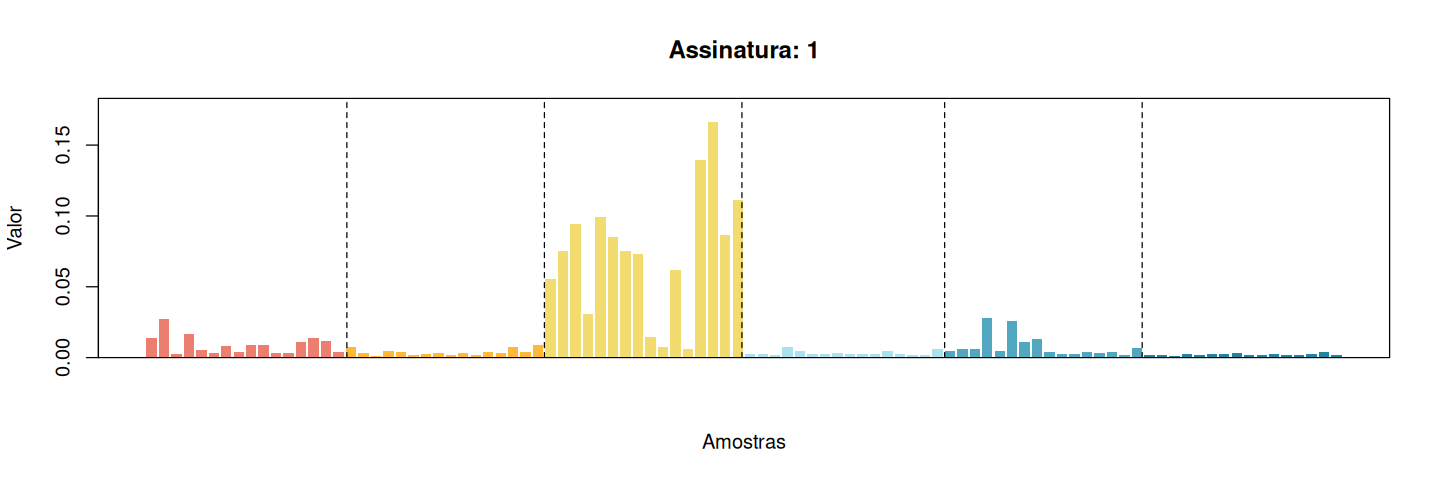

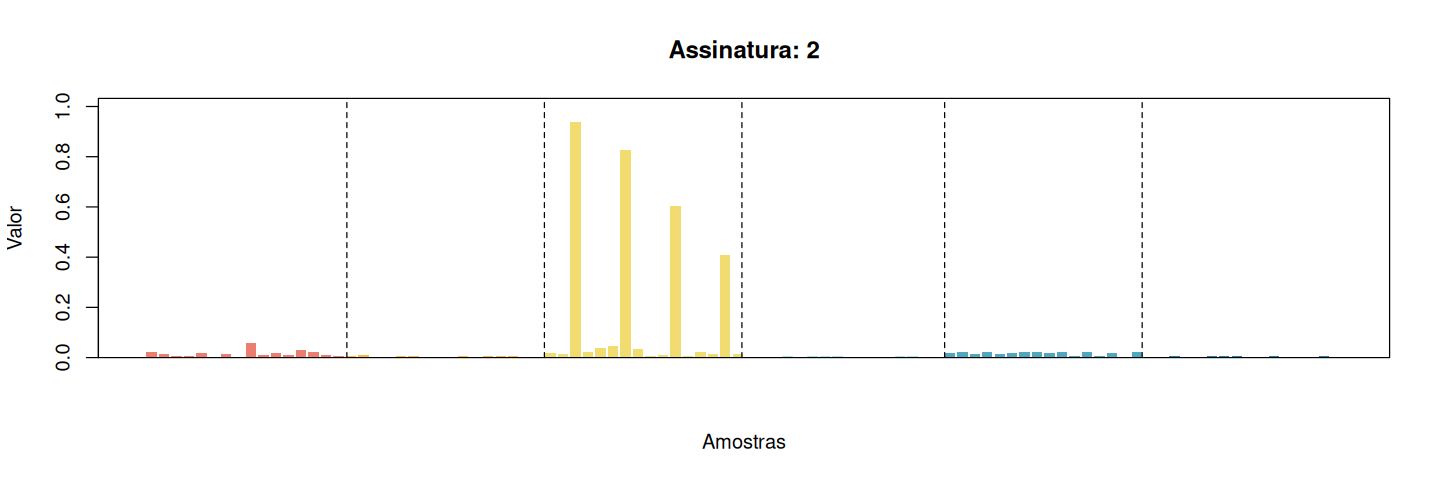

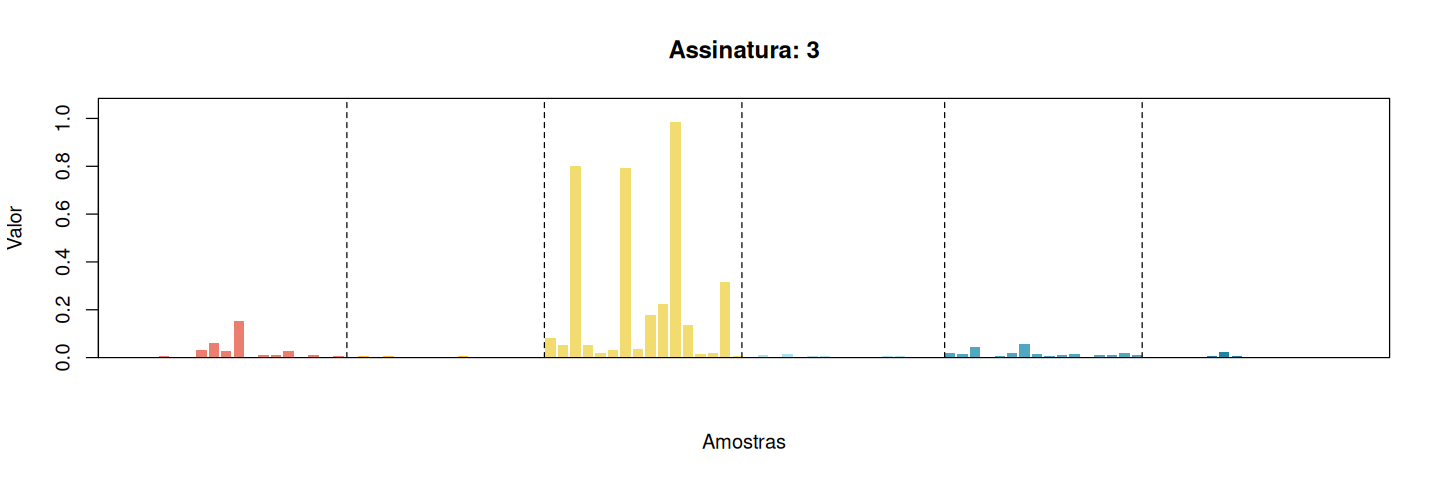

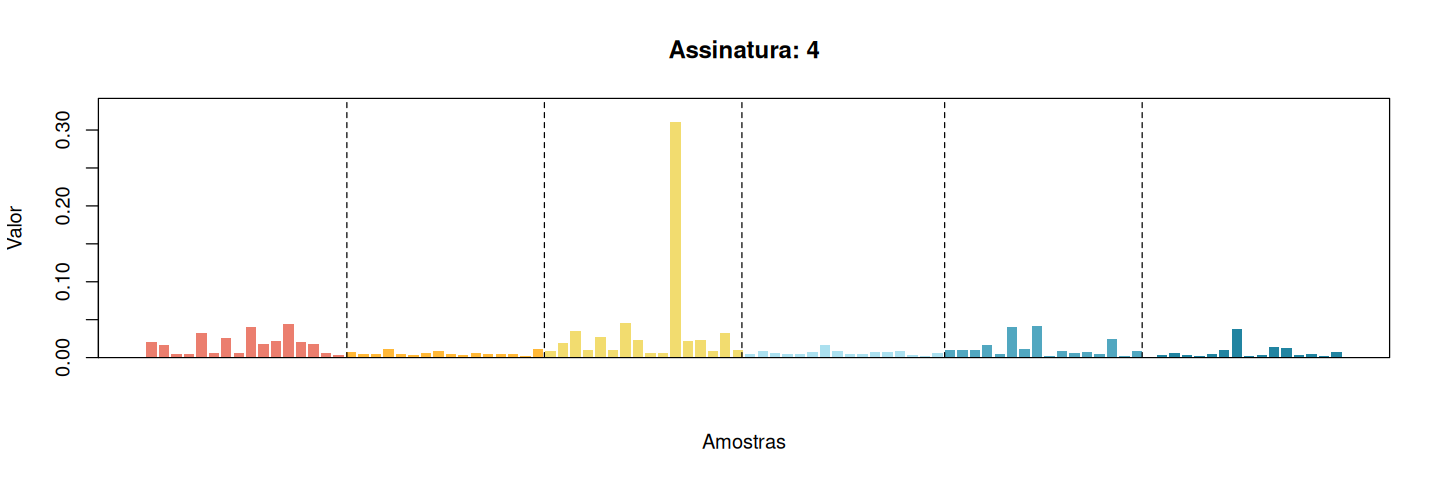

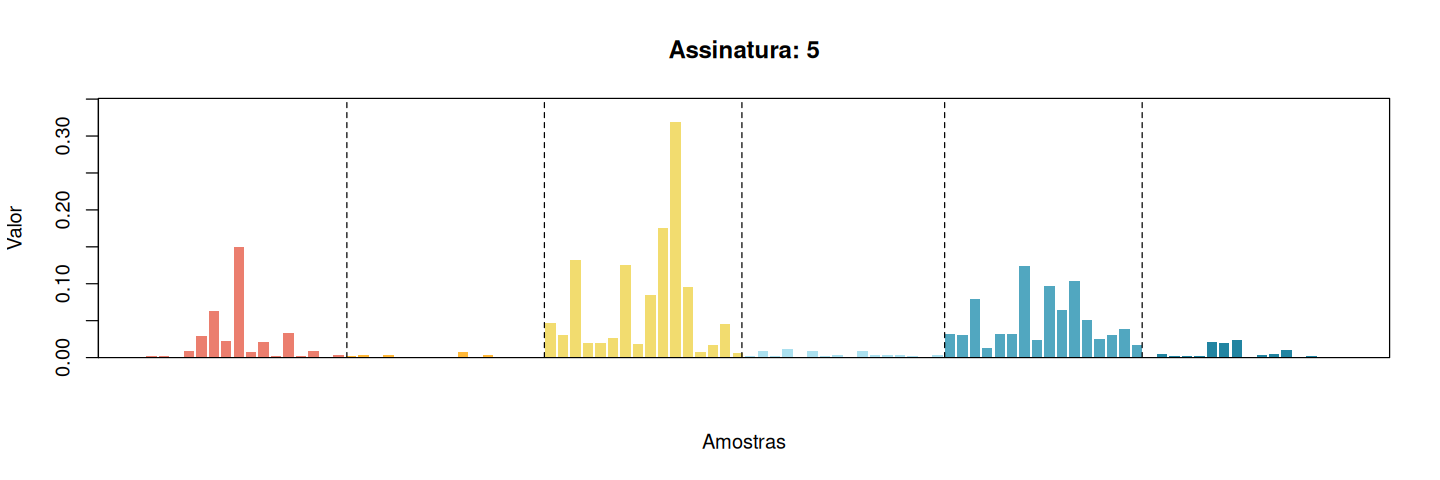

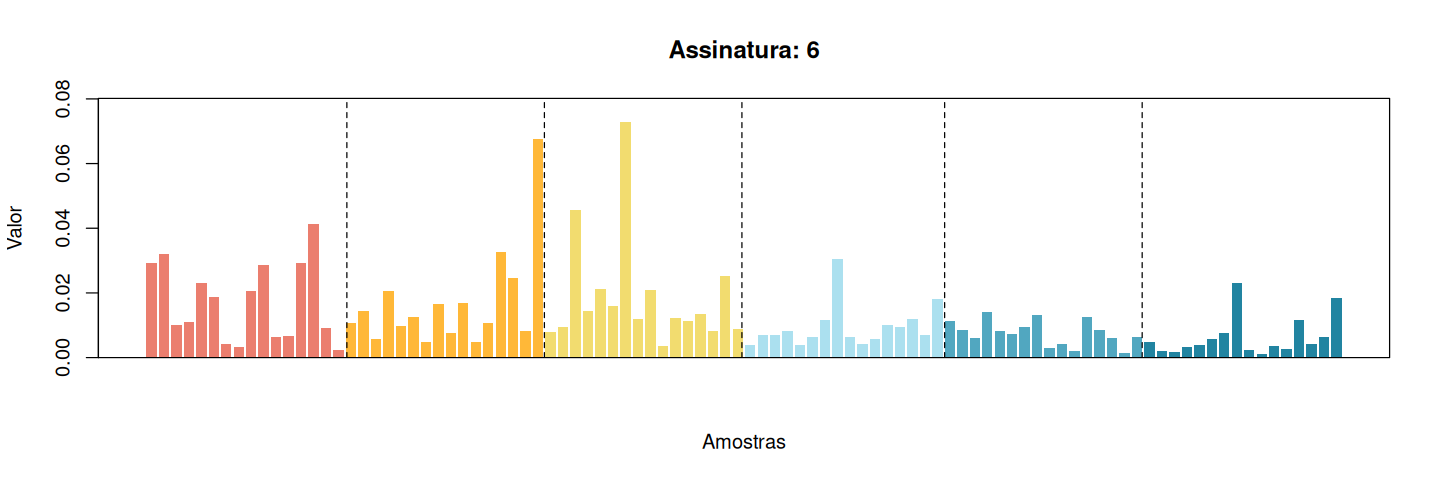

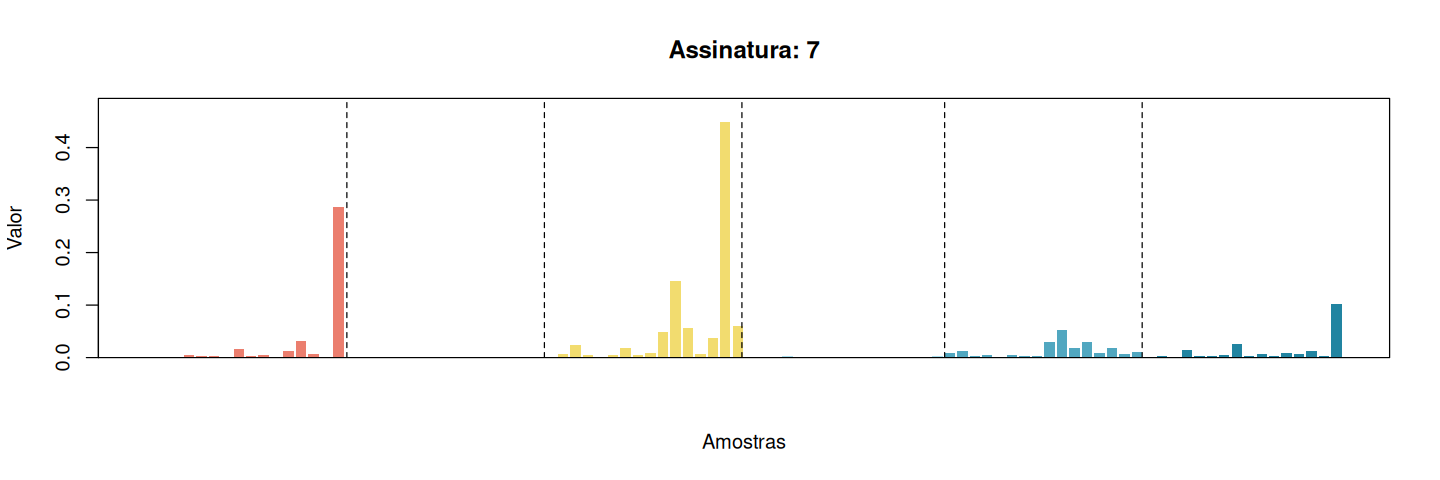

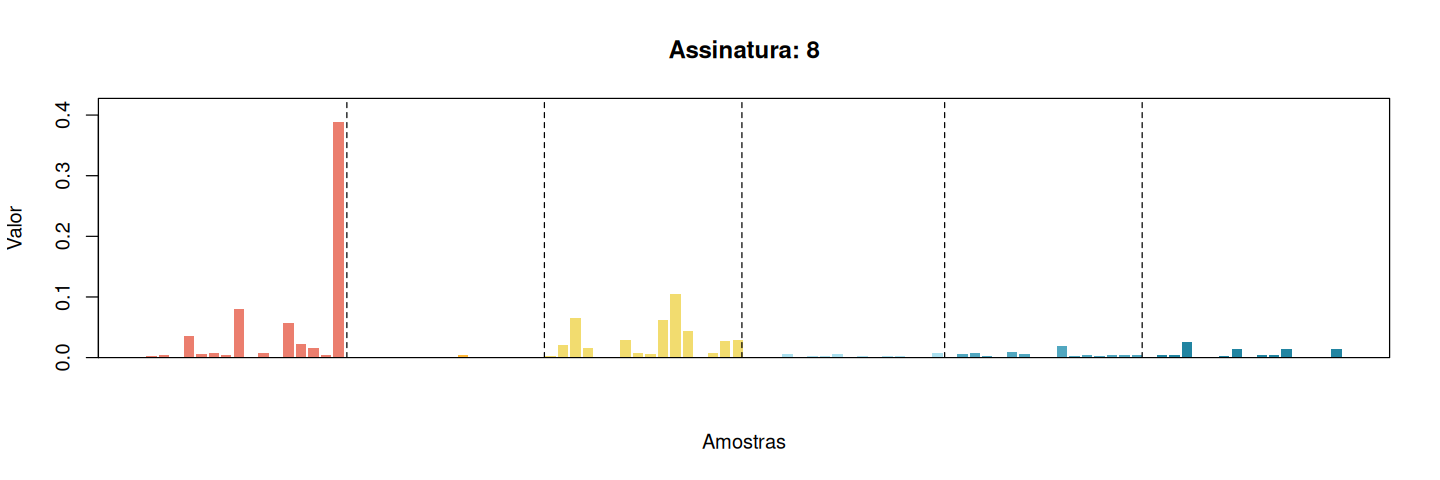

In [53]:
display_markdown("## Assinaturas mutacionais")

C3 <- c(
  rep("#EB7E6E", 16),
  rep("#FFB838", 16),
  rep("#F2DC6F", 16),
  rep("#ABE0EF", 16),
  rep("#51A7C0", 16),
  rep("#2184A1", 16)
)

Assinaturas_Mutacionais(dados$P_medio, cores = C3)

In [16]:
display_markdown(" ## Distância do coseno indicando qual é a assinatura COSMIC")

resultado_dist <- comparar_assinaturas_COSMIC(
  P_mat = dados$P,
  arquivo_COSMIC = "COSMIC_v3.1_SBS_GRCh37.signeR.txt",
  limiar_dist = 0.8
)

print(resultado_dist)

 ## Distância do coseno indicando qual é a assinatura COSMIC

  Assinatura_P1 Melhor_COSMIC  Distancia              Status
1          Sig1         SBS40 0.29868872 Detectada no COSMIC
2          Sig2        SBS10b 0.20819710 Detectada no COSMIC
3          Sig3          SBS6 0.15464889 Detectada no COSMIC
4          Sig4          SBS6 0.09517838 Detectada no COSMIC


## Box Plot – Exposição (Todos os Estudos)

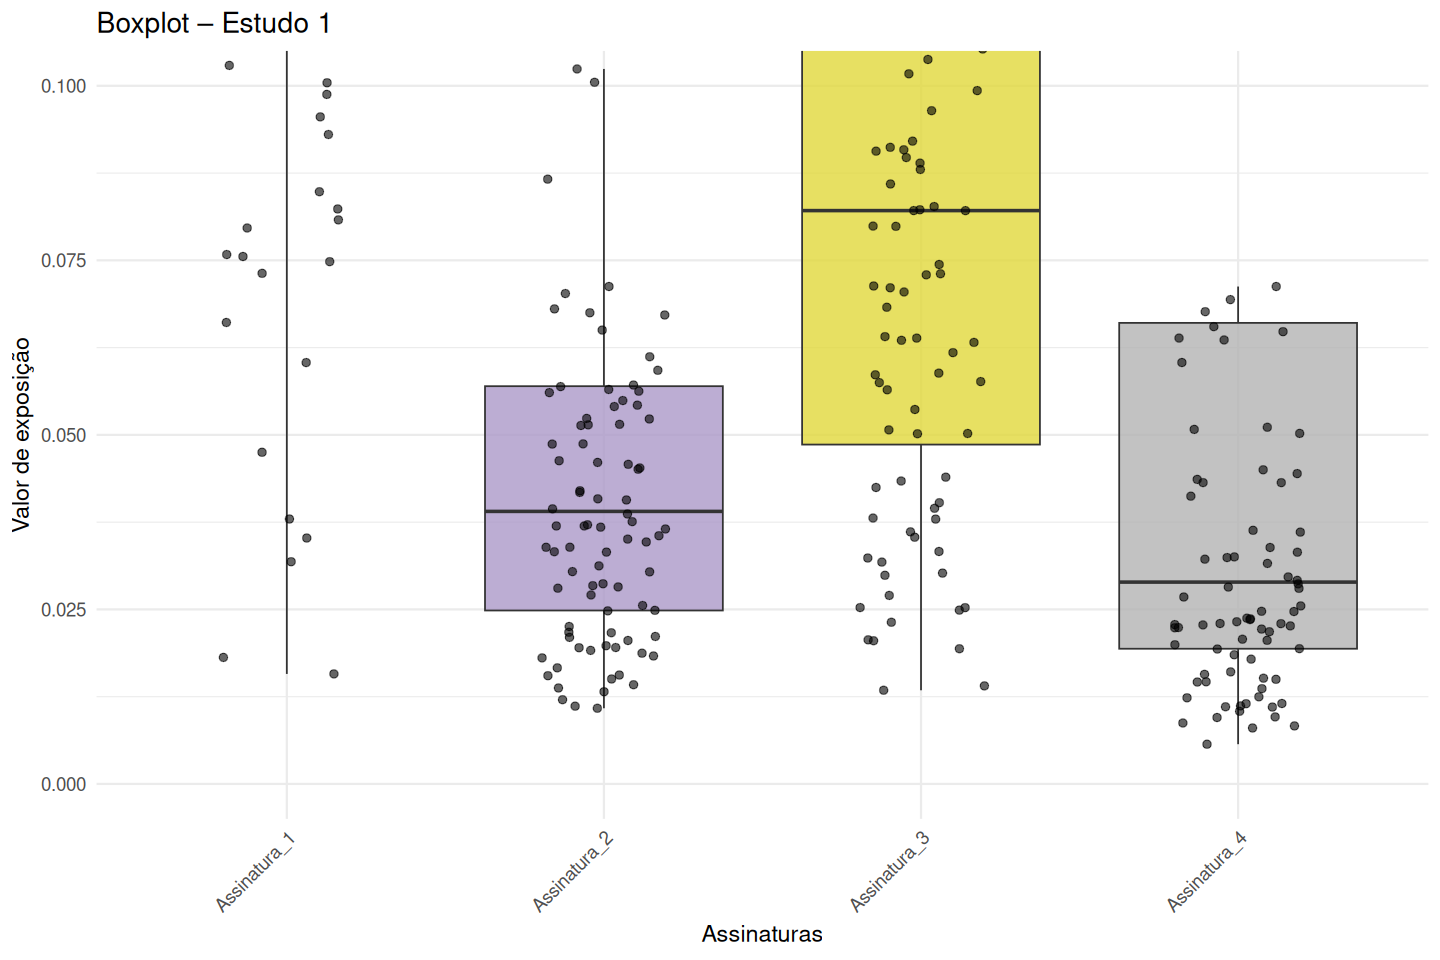

In [17]:
# ============================
# Título geral
# ============================
display_markdown("## Box Plot – Exposição (Todos os Estudos)")

# ============================
# Ajuste do tamanho do gráfico
# ============================
options(repr.plot.width = 12, repr.plot.height = 8)

# ============================
# Loop para TODOS os idx existentes
# ============================
for (i in seq_along(dados$E_list_medio)) {

#  display_markdown(paste0("### Estudo ", i))

  p <- Boxplot_exposicoes(
    E_list_medio,
    idx = i,
    ylim = c(0, 0.1),
    titulo = paste("Boxplot – Estudo", i)
  )

  print(p)   
}

In [18]:
#Boxplot Exposição visualisação individual

#display_markdown(" ## Box Plot Exposição")

        # Ajusta tamanho do gráfico
#options(repr.plot.width = 12, repr.plot.height = 8)

#Boxplot_exposicoes(
#  E_list_medio,
#  idx = 2,    # <----------- Escolhe o estudo 1, 2, 3, 4, 5 e etc.
#  ylim = c(0, 0.2),
#  titulo = "Boxplot"
#)

## Barplot Exposição (Todos os Estudos)

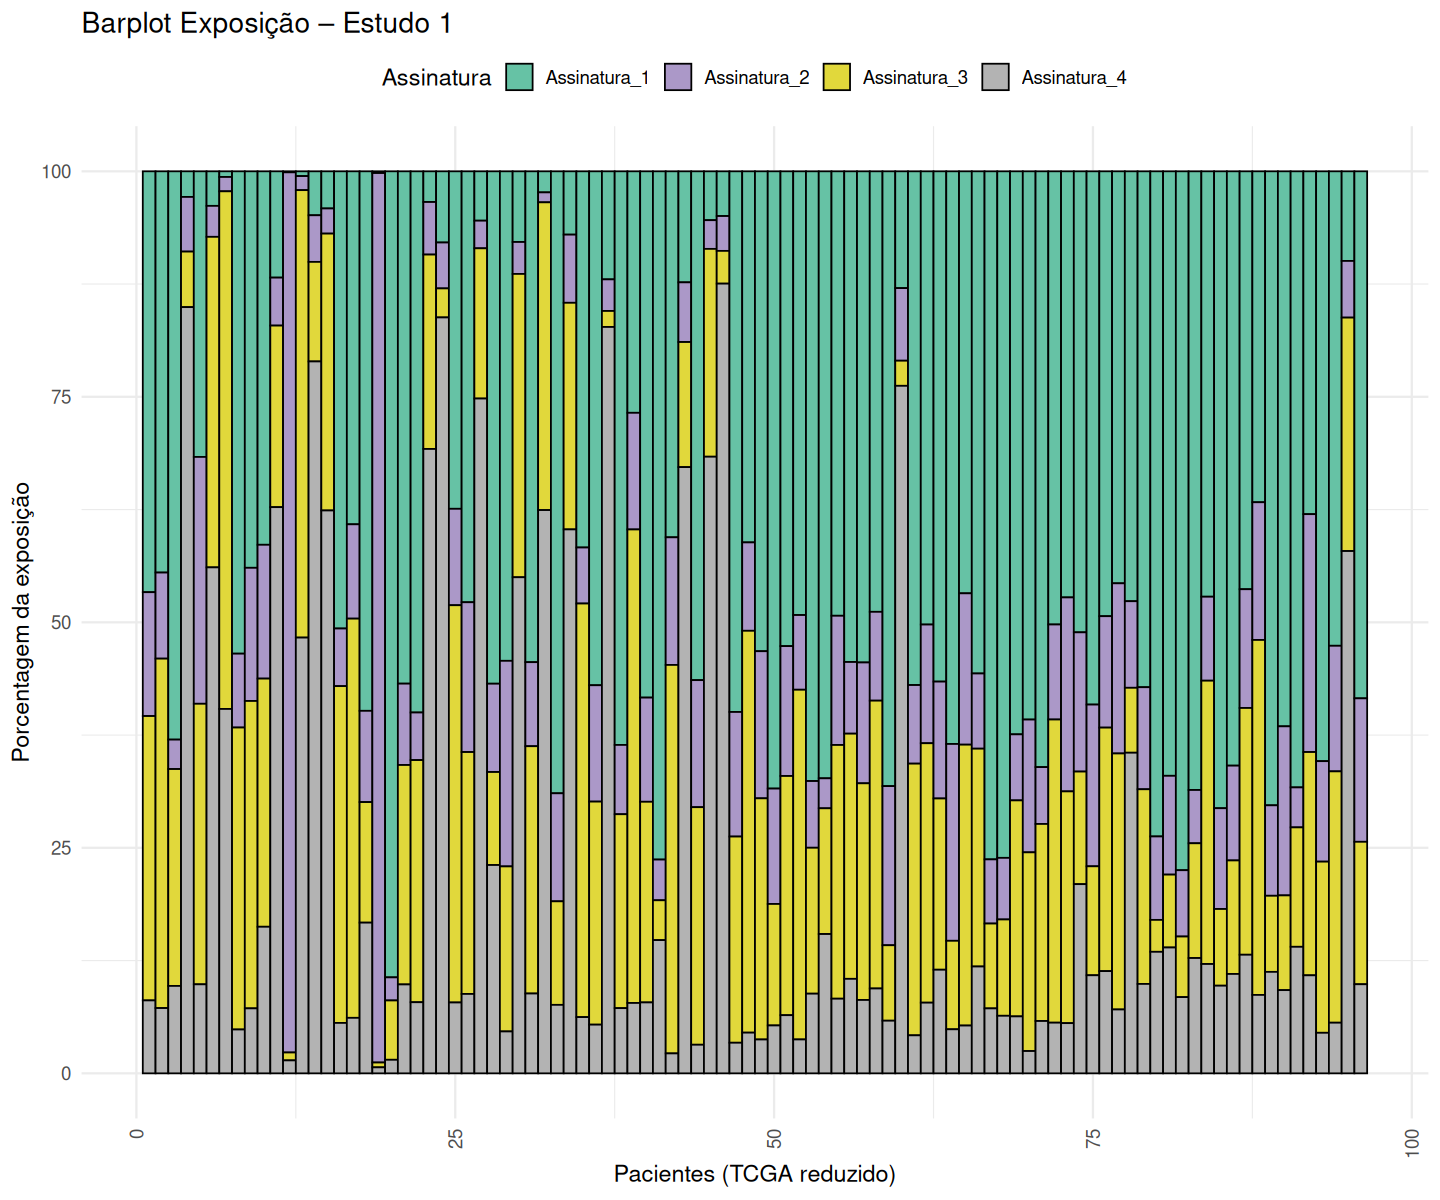

In [19]:
library(IRdisplay)

# ============================
# Título geral
# ============================
display_markdown("## Barplot Exposição (Todos os Estudos)")

# ============================
# Ajuste do tamanho do gráfico
# ============================
options(repr.plot.width = 12, repr.plot.height = 10)

# ============================
# Loop automático para TODOS os idx existentes
# ============================
for (i in seq_along(E_list_medio)) {

#  display_markdown(paste0("### Estudo ", i))

  p <- Barplot_exposição(
    E_list_medio,
    idx = i,
    titulo = paste("Barplot Exposição – Estudo", i)
  )

  print(p)   # <<< ESSENCIAL no loop
}

In [20]:
#Barplot Exposição ajuste individual
#display_markdown(" ## Barplot Exposição")

# Ajusta tamanho do gráfico
#options(repr.plot.width = 12, repr.plot.height = 8)

#Barplot_exposição(
#  E_list_medio,
#  idx = 2,  # <----------- Escolhe o estudo 1, 2, 3, 4, 5 e etc.
#  titulo = "Barplot Exposição"
#)

In [21]:
#dados1 <- readRDS("COAD_MATH_SIGNER_N8.rds")


#----------------------> Como acessar cada objeto <------------------------
# É preciso desabilitar P, E ou A que seja de interesse em fixar -------------


#dados$P_medio                   
#dados$E_list_medio 
#dados$A_list
#dados$BIC 
#dados$Menor_Math_Score_BLCA_S
#dados$Maior_Math_Score_BLCA_S   
#dados$dados_survival
#dados$informacoes 

In [22]:
#saveRDS(list(dados1 = dados1,
#             dados2 = dados2),
#        file = "BLCA_R10_MATH_SCORE_S_Rcpp.rds")